# Hands-on 02 Analysis: Claude Code vs Gemini CLI

This notebook performs a comparison between the statistical results generated by two different AI agents for the CAP 417 Hands-on 02 assignment. It analyzes moments of Brownian series and colored noise realizations.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Normalize noise names for comparison
def normalize(name):
    name = name.lower()
    if 'white' in name: return 'White'
    if 'pink' in name: return 'Pink'
    if 'red' in name: return 'Red'
    return name

# Load data
df_claude = pd.read_csv('claude-code/results/noise_moments.csv')
df_gemini = pd.read_csv('gemini-cli/results/noise_moments.csv')

df_claude['Type'] = df_claude['noise_type'].apply(normalize)
df_gemini['Type'] = df_gemini['Type'].apply(normalize)

print("Data loaded successfully.")

Data loaded successfully.


## 1. Visual Comparison of CFP Clusters
We compare the Skewness vs Kurtosis clusters generated by both agents.

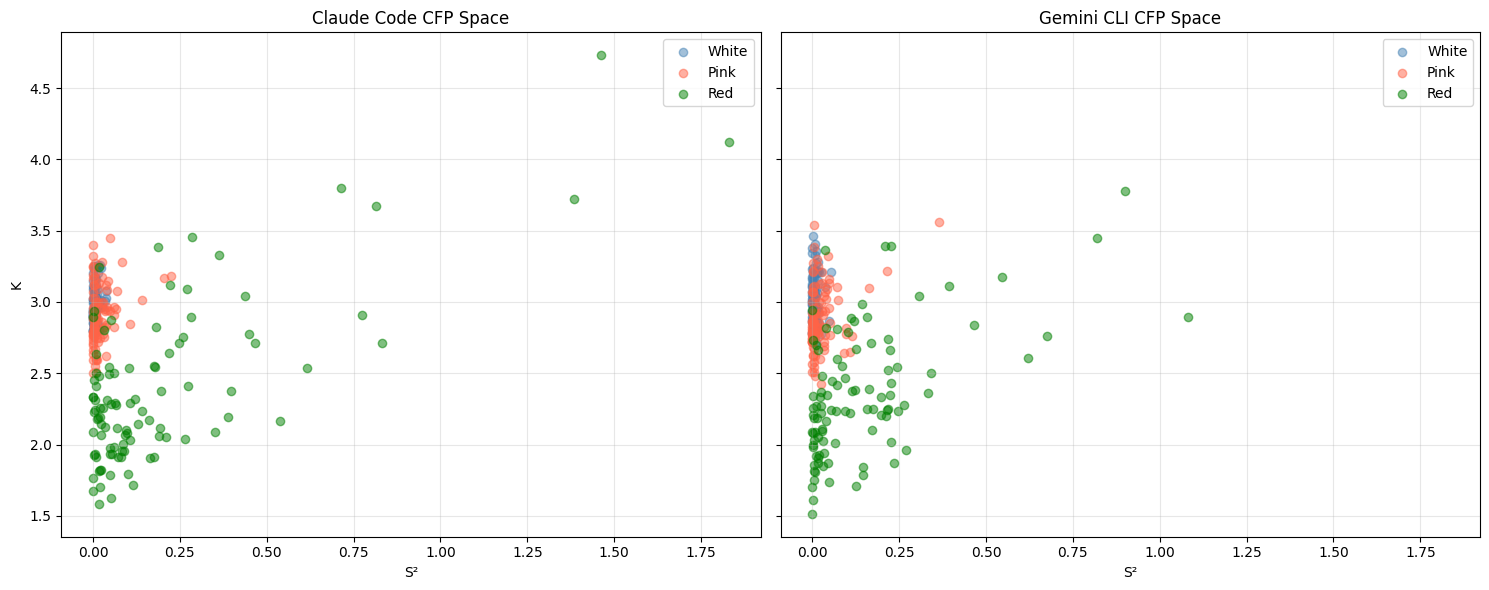

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

colors = {'White': 'steelblue', 'Pink': 'tomato', 'Red': 'green'}

for nt in ['White', 'Pink', 'Red']:
    c_sub = df_claude[df_claude['Type'] == nt]
    ax1.scatter(c_sub['skewness_sq'], c_sub['kurtosis_raw'], label=nt, color=colors[nt], alpha=0.5)
    
    g_sub = df_gemini[df_gemini['Type'] == nt]
    ax2.scatter(g_sub['SkewnessSq'], g_sub['Kurtosis'], label=nt, color=colors[nt], alpha=0.5)

ax1.set_title("Claude Code CFP Space")
ax1.set_xlabel("S²")
ax1.set_ylabel("K")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title("Gemini CLI CFP Space")
ax2.set_xlabel("S²")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Statistical Moments Comparison
Comparison of average values for Skewness and Kurtosis per noise type.

In [18]:
comp_df = pd.read_csv('benchmark/moments_comparison.csv')
comp_df

,noise_type,metric,claude_mean,claude_std,gemini_mean,gemini_std,abs_diff_mean
0,White,skewness,-0.000409,0.078561,0.007544,0.081675,0.007953
1,White,kurtosis_raw,2.979142,0.121924,3.017831,0.166893,0.038689
2,Pink,skewness,0.026860,0.144076,-0.012504,0.160603,0.039365
3,Pink,kurtosis_raw,2.915689,0.202897,2.887722,0.223931,0.027967
4,Red,skewness,-0.021122,0.437193,-0.070611,0.373945,0.049489
5,Red,kurtosis_raw,2.391685,0.560213,2.357699,0.447387,0.033986


## 3. Textbook-Quality Cullen-Frey Plot
This chart includes theoretical regions and lines for standard distributions: 
- **Normal Point**: (0, 3)
- **Uniform Point**: (0, 1.8)
- **Exponential Point**: (4, 9)
- **Logistic Point**: (0, 4.2)
- **Gamma Line**: $K = 3 + 1.5 S^2$
- **Log-normal Line**: Parametric curve

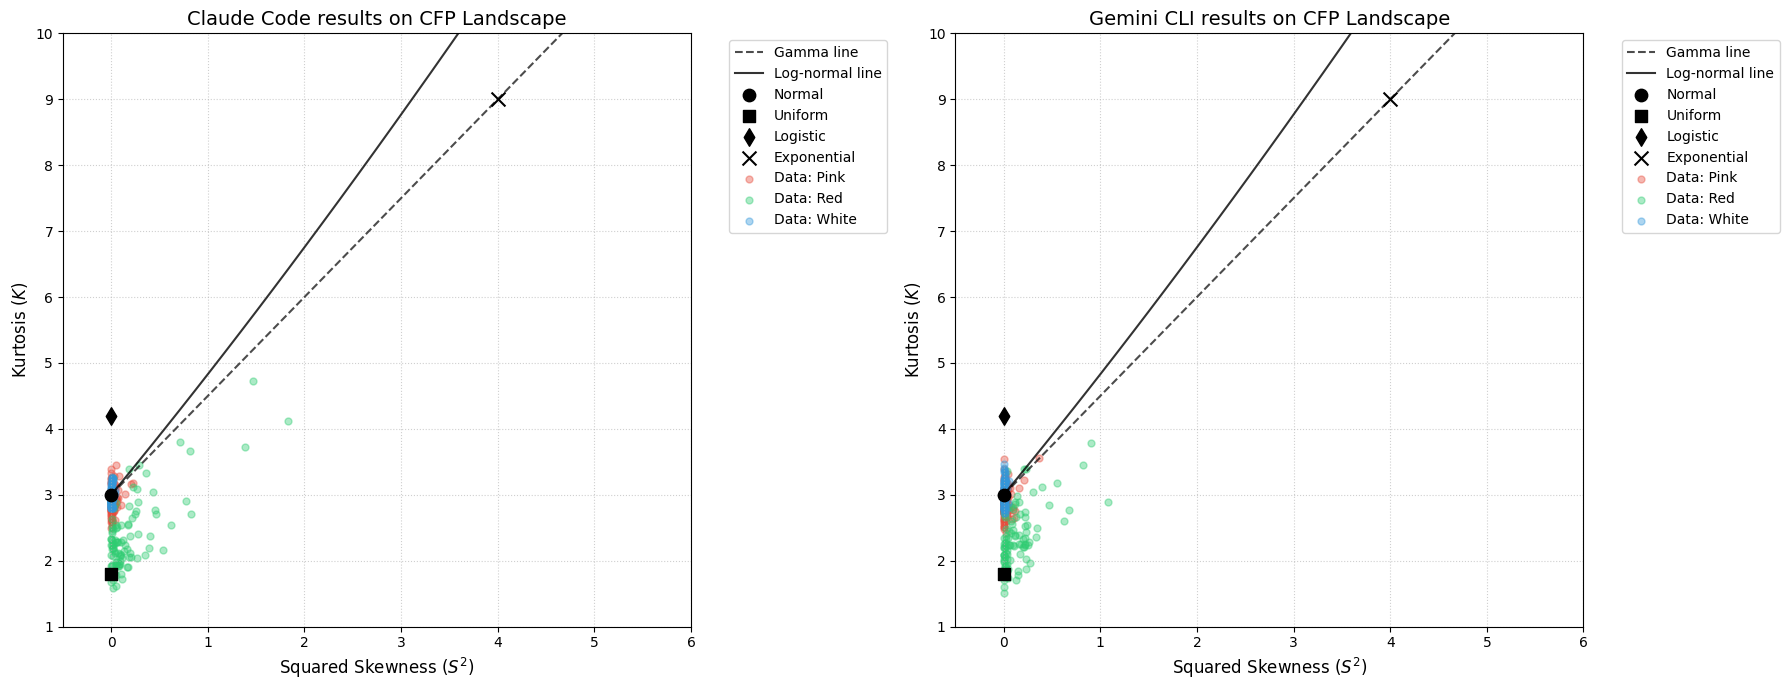

In [19]:
def plot_textbook_cullen_frey(ax, df_data, title):
    # 1. Theoretical Lines
    s2_gamma = np.linspace(0, 10, 100)
    k_gamma = 3 + 1.5 * s2_gamma
    
    # Log-normal: s2 = (w-1)(w+2)^2, k = w^4 + 2w^3 + 3w^2 - 3 where w = exp(sigma^2)
    w = np.linspace(1, 2.5, 100)
    s2_lognorm = (w - 1) * (w + 2)**2
    k_lognorm = w**4 + 2*w**3 + 3*w**2 - 3
    
    ax.plot(s2_gamma, k_gamma, 'k--', label='Gamma line', alpha=0.7)
    ax.plot(s2_lognorm, k_lognorm, 'k-', label='Log-normal line', alpha=0.8)
    
    # 2. Fixed Points
    ax.scatter(0, 3, color='black', marker='o', s=80, label='Normal', zorder=5)
    ax.scatter(0, 1.8, color='black', marker='s', s=80, label='Uniform', zorder=5)
    ax.scatter(0, 4.2, color='black', marker='d', s=80, label='Logistic', zorder=5)
    ax.scatter(4, 9, color='black', marker='x', s=100, label='Exponential', zorder=5)
    
    # 3. Agent Data
    colors = {'White': '#3498db', 'Pink': '#e74c3c', 'Red': '#2ecc71'}
    # Detect column names based on agent
    s2_col = 'skewness_sq' if 'skewness_sq' in df_data.columns else 'SkewnessSq'
    k_col = 'kurtosis_raw' if 'kurtosis_raw' in df_data.columns else 'Kurtosis'
    
    for label, group in df_data.groupby('Type'):
        ax.scatter(group[s2_col], group[k_col], 
                   alpha=0.4, label=f'Data: {label}', color=colors.get(label, 'gray'), s=25)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Squared Skewness ($S^2$)', fontsize=12)
    ax.set_ylabel('Kurtosis ($K$)', fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(-0.5, 6)
    ax.set_ylim(1, 10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
plot_textbook_cullen_frey(ax1, df_claude, "Claude Code results on CFP Landscape")
plot_textbook_cullen_frey(ax2, df_gemini, "Gemini CLI results on CFP Landscape")
plt.tight_layout()
plt.show()

## 4. Theoretical GEV Analysis

This analysis required Claude Opus 4.7, a state of the art model at the time of writing.

The **Generalized Extreme Value (GEV) distribution** describes the limit law of properly normalized sample maxima (Fisher–Tippett–Gnedenko theorem). Its CDF is

$$F(x;\,\mu,\sigma,\xi)\;=\;\exp\!\Bigl\{-\bigl[\,1+\xi\,z\,\bigr]^{-1/\xi}\Bigr\},\qquad z=\tfrac{x-\mu}{\sigma},\quad 1+\xi z>0,$$

with $\mu\in\mathbb{R}$ the **location**, $\sigma>0$ the **scale**, and $\xi\in\mathbb{R}$ the **shape**. The shape selects one of three sub-families:

| Sub-family | Shape | Tail / support |
|------------|-------|---------------|
| **Weibull** (Type III) | $\xi<0$ | bounded above |
| **Gumbel**  (Type I)  | $\xi\to 0$ | exponential tail |
| **Fréchet** (Type II) | $\xi>0$ | heavy power-law tail |

### Moments via the Gamma function

Define the auxiliary quantities
$$g_k\;\equiv\;\Gamma\!\bigl(1-k\,\xi\bigr),\qquad k=1,2,3,4,$$
where **$k$ is the order of the moment** ($k=1$ for the mean, $2$ for the variance, $3$ for skewness, $4$ for kurtosis). Each $g_k$ exists only when $\xi<1/k$, so

* $\mathbb{E}[X]$ exists for $\xi<1$,
* $\mathrm{Var}[X]$ exists for $\xi<1/2$,
* $S(\xi)$ exists for $\xi<1/3$,
* $K(\xi)$ exists for $\xi<1/4$.

The first four (central) moments are then

$$
\begin{aligned}
\mathbb{E}[X] &= \mu+\sigma\,\dfrac{g_1-1}{\xi}, \\[4pt]
\mathrm{Var}[X] &= \sigma^{2}\,\dfrac{g_2-g_1^{2}}{\xi^{2}}, \\[4pt]
S(\xi) &= \mathrm{sign}(\xi)\,\dfrac{g_3-3\,g_1g_2+2\,g_1^{3}}{(g_2-g_1^{2})^{3/2}}, \\[4pt]
K(\xi) &= \dfrac{g_4-4\,g_1g_3+6\,g_2g_1^{2}-3\,g_1^{4}}{(g_2-g_1^{2})^{2}}\quad\text{(raw, not excess)}.
\end{aligned}
$$

Two consequences are central for what follows:

1. **$S$ and $K$ depend only on $\xi$** — they are invariant under location and scale. So each $\xi$ maps to a *single* point $(S^{2},K)$ in the Cullen–Frey diagram, and the GEV family traces a **one-dimensional curve** there.
2. The **Gumbel limit** $\xi\to 0$ gives the closed-form constants
$$S_{\text{Gumbel}}=\dfrac{12\sqrt{6}\,\zeta(3)}{\pi^{3}}\approx 1.1396,\qquad K_{\text{Gumbel}}=\dfrac{27}{5}=5.4,$$
i.e. $(S^{2},K)\approx(1.30,\,5.4)$.

Symmetric-Weibull shape (zero skewness): xi = -0.2776


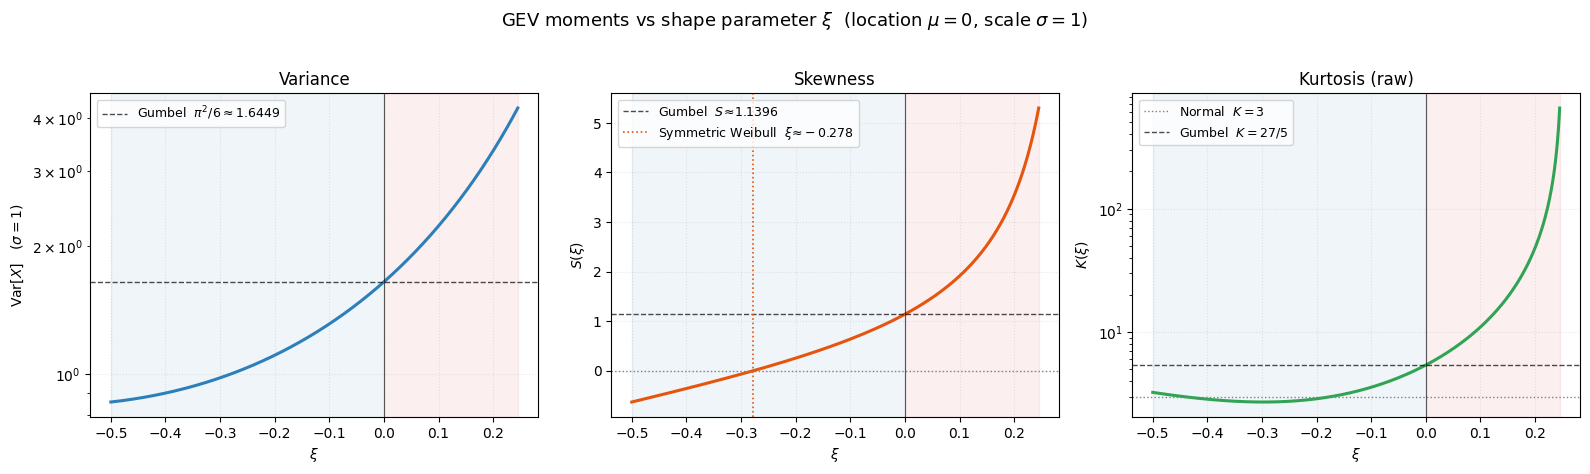

In [20]:
from scipy.stats import genextreme
from scipy.optimize import brentq


def gev_moments(xi):
    """GEV variance (sigma=1), skewness and raw kurtosis as functions of xi.

    Uses scipy's `genextreme` (shape parameter c = -xi) so the Gumbel limit
    near xi=0 is handled internally without the catastrophic cancellation
    that affects a naive g_k = Gamma(1 - k*xi) implementation.
    """
    xi = np.atleast_1d(np.asarray(xi, dtype=float))
    var = np.atleast_1d(np.asarray(genextreme.var(-xi, scale=1.0),  dtype=float))
    skew, exc_kurt = genextreme.stats(-xi, moments='sk')
    skew     = np.atleast_1d(np.asarray(skew,     dtype=float))
    exc_kurt = np.atleast_1d(np.asarray(exc_kurt, dtype=float))
    return var, skew, exc_kurt + 3.0   # raw kurtosis


def _skew_only(x):
    return float(genextreme.stats(-x, moments='s'))


# Locate the symmetric-Weibull (zero-skewness) shape numerically
xi_zero_skew = brentq(_skew_only, -0.30, -0.25)
print(f"Symmetric-Weibull shape (zero skewness): xi = {xi_zero_skew:.4f}")

# Sweep xi up to just below 1/4 (where K diverges)
xis = np.linspace(-0.5, 0.245, 600)
var_xi, skew_xi, kurt_xi = gev_moments(xis)

# Three-panel figure: Variance, Skewness, Kurtosis vs xi
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
fig.suptitle(r'GEV moments vs shape parameter $\xi$  '
             r'(location $\mu=0$, scale $\sigma=1$)',
             fontsize=13, y=1.02)

# Variance ------------------------------------------------------------
axes[0].plot(xis, var_xi, lw=2.2, color='#2c7fb8')
axes[0].axhline(np.pi**2 / 6, ls='--', color='black', lw=1, alpha=0.7,
                label=r'Gumbel  $\pi^{2}/6\approx1.6449$')
axes[0].set_yscale('log')
axes[0].set_title('Variance')
axes[0].set_xlabel(r'$\xi$'); axes[0].set_ylabel(r'$\mathrm{Var}[X]\quad(\sigma=1)$')
axes[0].legend(loc='upper left', fontsize=9)

# Skewness ------------------------------------------------------------
axes[1].plot(xis, skew_xi, lw=2.2, color='#e6550d')
axes[1].axhline(0, ls=':', color='gray', lw=1)
axes[1].axhline(12*np.sqrt(6)*1.2020569/np.pi**3, ls='--', color='black',
                lw=1, alpha=0.7, label=r'Gumbel  $S\!\approx\!1.1396$')
axes[1].axvline(xi_zero_skew, ls=':', color='#e6550d', lw=1.2,
                label=fr'Symmetric Weibull  $\xi\!\approx\!{xi_zero_skew:.3f}$')
axes[1].set_title('Skewness')
axes[1].set_xlabel(r'$\xi$'); axes[1].set_ylabel(r'$S(\xi)$')
axes[1].legend(loc='upper left', fontsize=9)

# Kurtosis ------------------------------------------------------------
axes[2].plot(xis, kurt_xi, lw=2.2, color='#31a354')
axes[2].axhline(3.0, ls=':', color='gray', lw=1, label=r'Normal  $K=3$')
axes[2].axhline(5.4, ls='--', color='black', lw=1, alpha=0.7,
                label=r'Gumbel  $K=27/5$')
axes[2].set_yscale('log')
axes[2].set_title('Kurtosis (raw)')
axes[2].set_xlabel(r'$\xi$'); axes[2].set_ylabel(r'$K(\xi)$')
axes[2].legend(loc='upper left', fontsize=9)

# Shade the three regimes on every panel
for ax in axes:
    ax.axvspan(-0.5, 0,    alpha=0.07, color='#1f77b4')   # Weibull
    ax.axvspan( 0,    0.245, alpha=0.07, color='#d62728')  # Frechet
    ax.axvline(0, color='black', lw=0.8, alpha=0.6)
    ax.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

### The GEV trajectory in Cullen–Frey space

Because $S(\xi)$ and $K(\xi)$ are independent of the location $\mu$ and scale $\sigma$, sweeping $\xi$ from the deep Weibull range up to (just below) $\xi=1/4$ traces a **one-parameter curve** in the $(S^{2},K)$ plane. Three landmarks orient this curve:

* **Gumbel** at $\xi=0$, sitting at $(S^{2},K)=(1.30,\;5.4)$;
* a **symmetric-Weibull turning point** near $\xi\!\approx\!-0.278$ where $S(\xi)=0$ and $K$ attains its GEV minimum $K\!\approx\!2.71$ (the curve rebounds back toward $S^{2}=0$);
* a **divergence** as $\xi\to (1/4)^{-}$, where $K\to\infty$ and the trajectory escapes to the upper-right (heavy Fréchet tails).

We now overlay this trajectory on the textbook Cullen–Frey backdrop, colouring it by $\xi$ to expose how the shape parameter maps to position in the diagram, and contrasting it against the fixed-distribution landmarks (Normal, Uniform, Logistic, Exponential), the Gamma line, and the Log-normal curve.

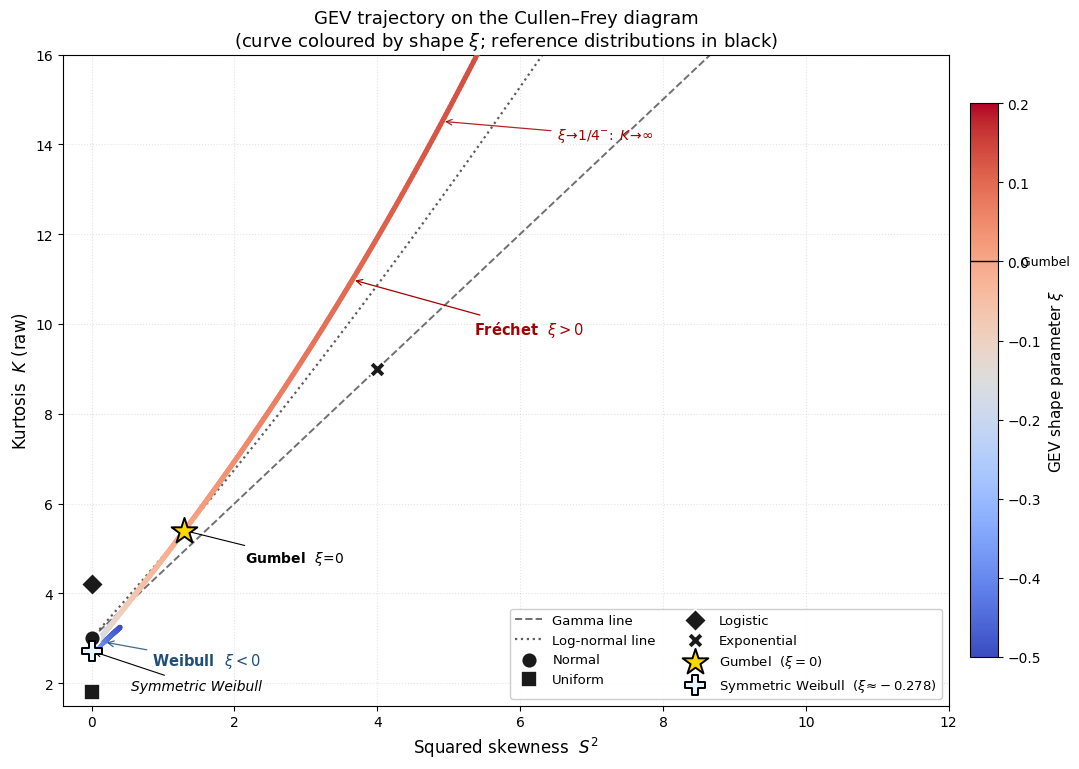

In [21]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Sweep xi over a range where the curve stays inside the plotting window;
# the Frechet branch diverges as xi -> 1/4, so cap below that for legibility.
xi_curve = np.linspace(-0.5, 0.20, 1500)
_, S_curve, K_curve = gev_moments(xi_curve)
S2_curve = S_curve ** 2

# Coloured LineCollection encodes xi along the curve
points = np.array([S2_curve, K_curve]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

cmap = plt.get_cmap('coolwarm')
norm = Normalize(vmin=xi_curve.min(), vmax=xi_curve.max())
lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=3.6, zorder=4,
                    capstyle='round', joinstyle='round')
lc.set_array(xi_curve[:-1])

fig, ax = plt.subplots(figsize=(11.5, 7.8))
fig.patch.set_facecolor('white')

# --- Cullen–Frey backdrop ----------------------------------------------
s2_ref = np.linspace(0, 14, 400)
ax.plot(s2_ref, 3 + 1.5 * s2_ref, ls='--', color='#404040', lw=1.4,
        alpha=0.75, label='Gamma line', zorder=2)

w = np.linspace(1.0, 2.6, 400)
ax.plot((w - 1) * (w + 2)**2, w**4 + 2*w**3 + 3*w**2 - 3,
        ls=':', color='#404040', lw=1.6, alpha=0.85,
        label='Log-normal line', zorder=2)

# Reference distributions
ref_pts = [(0.0, 3.0,  'o', 'Normal'),
           (0.0, 1.8,  's', 'Uniform'),
           (0.0, 4.2,  'D', 'Logistic'),
           (4.0, 9.0,  'X', 'Exponential')]
for s2, k, m, name in ref_pts:
    ax.scatter(s2, k, marker=m, s=130, color='#1a1a1a',
               edgecolor='white', linewidth=1.2, zorder=7, label=name)

# --- GEV trajectory ---------------------------------------------------
ax.add_collection(lc)

# Gumbel (xi = 0)
S_g, K_g = 12 * np.sqrt(6) * 1.2020569 / np.pi**3, 27.0 / 5.0
ax.scatter(S_g**2, K_g, marker='*', s=380, color='gold',
           edgecolor='black', linewidth=1.4, zorder=9,
           label=r'Gumbel  ($\xi=0$)')
ax.annotate(r'Gumbel  $\xi\!=\!0$',
            xy=(S_g**2, K_g), xytext=(S_g**2 + 0.85, K_g - 0.7),
            fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='-', color='black', lw=0.8))

# Symmetric Weibull (zero skewness)
_, S_sym, K_sym = gev_moments(np.array([xi_zero_skew]))
ax.scatter(S_sym[0]**2, K_sym[0], marker='P', s=200, color='#e6f5ff',
           edgecolor='black', linewidth=1.4, zorder=9,
           label=fr'Symmetric Weibull  ($\xi\!\approx\!{xi_zero_skew:.3f}$)')
ax.annotate(r'Symmetric Weibull',
            xy=(S_sym[0]**2, K_sym[0]),
            xytext=(0.55, 1.85),
            fontsize=10, fontstyle='italic',
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

# Inline branch labels --------------------------------------------------
i_w = np.argmin(np.abs(xi_curve + 0.42))
ax.annotate(r'Weibull  $\xi<0$',
            xy=(S2_curve[i_w], K_curve[i_w]),
            xytext=(0.85, 2.4),
            fontsize=10.5, color='#1f4e79', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#1f4e79', lw=0.9, alpha=0.85))

i_f = np.argmin(np.abs(xi_curve - 0.10))
ax.annotate(r'Fréchet  $\xi>0$',
            xy=(S2_curve[i_f], K_curve[i_f]),
            xytext=(S2_curve[i_f] + 1.7, K_curve[i_f] - 1.2),
            fontsize=10.5, color='#a30000', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#a30000', lw=0.9))

# Indicate where xi -> 1/4 sends the curve (anchor inside frame)
i_top = np.argmin(np.abs(K_curve - 14.5))
ax.annotate(r'$\xi\!\to\!1/4^{-}\!:\;K\!\to\!\infty$',
            xy=(S2_curve[i_top], K_curve[i_top]),
            xytext=(S2_curve[i_top] + 1.6, K_curve[i_top] - 0.4),
            fontsize=10, color='#a30000',
            arrowprops=dict(arrowstyle='->', color='#a30000', lw=0.9, alpha=0.85))

# Colorbar for xi
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),
                    ax=ax, pad=0.02, shrink=0.85)
cbar.set_label(r'GEV shape parameter $\xi$', fontsize=11)
cbar.ax.axhline(0, color='black', lw=1.0)
cbar.ax.text(1.55, 0, '  Gumbel', va='center', fontsize=9,
             transform=cbar.ax.get_yaxis_transform())

ax.set_xlim(-0.4, 12)
ax.set_ylim(1.5, 16)
ax.set_xlabel(r'Squared skewness  $S^{2}$', fontsize=12)
ax.set_ylabel(r'Kurtosis  $K$ (raw)', fontsize=12)
ax.set_title('GEV trajectory on the Cullen–Frey diagram\n'
             r'(curve coloured by shape $\xi$; reference distributions in black)',
             fontsize=13)
ax.grid(True, alpha=0.35, linestyle=':')
ax.legend(loc='lower right', framealpha=0.95, fontsize=9.5, ncol=2)

plt.tight_layout()
plt.show()

## 5. Discussion Summary

1. Cullen-Frey does not differentiate the noise types well: white, pink and red noise are all generated from Gaussian samples, so spectral shaping leaves the marginal distribution unchanged and every cloud gravitates around the theoretical point of the Gaussian distribution. Red/brown noise scatters more widely only because its strong low-frequency content reduces the effective sample size, which inflates the sampling variance of the skewness and kurtosis estimators.
2. There is indeed overlap between the studied processes on the Cullen-Frey chart.
3. Skewness and kurtosis are interesting tools to describe distributions, and the Gamma, Log-normal and GEV families do trace distinct loci on this chart. They are nonetheless not sufficient to distinguish the coloured-noise classes studied here, since all three sit near the Gaussian point.
4. Shuffling does not alter skewness or kurtosis, as both are functions of the empirical distribution of values and are invariant under permutation. Therefore, shuffling also does not affect the position in Cullen-Frey space.
5. No questions at this moment.